# Can the legs be followed directly?

**The question:** every movement score so far is a proxy: how much the grey levels of a patch vary over the frames. None of them looks at a leg. Can the legs be found in the picture and followed as what they are, within a recording and from one recording to the next?

**The approach:** a mite is 14 pixels long and a leg 1 to 2 pixels wide, too little to cut a leg out and track it as an object. But the legs are what sticks out of the body, so they show in the mite's **outline**. Here the outline is unrolled around the mite's centre into a profile, one length per angle, and followed frame by frame and recording by recording. A change of it is a distance in pixels at a place on the mite, not a variance.

The run is the long one (`test_run_2026-09-08_Mathis_last_dsRNA`); the functions are in `scripts/alive_dead_features.py`. `alive_dead_overview.ipynb` sets the other hypotheses side by side.

## Findings (run of 8 October 2026)

One run, one plate, 54 mites that moved at least once and 5 that never did.

- **Yes: the legs can be seen moving, and seen to stop.** Unrolled over the run, each leg is a stripe that wavers while the mite lives and runs straight from one recording on. The pictures below show it for 8 mites without any threshold.
- **What moves within a recording is the legs.** In a recording labelled moving, 81% of the outline's movement lies in one third of the outline (33% by chance), the same third every time the mite moves, and it is the side the legs are on.
- **A moving mite's outline moves by about a third of a pixel.** 0.36 px in the middle for the recordings labelled moving, 0.09 px for those labelled still, and 999 still recordings in 1000 are below 0.27 px.
- **As a movement score it is as good as the one in use, not better.** AUC 0.996 against 0.997 for moving against still. At each one's best threshold the deaths are 4.2 recordings off with the outline and 3.5 with the score in use.
- **Between recordings it agrees with the change of the whole image.** The outline of a live mite changes by 0.11 px from one recording to the next, a dead one's by 0.02 px (AUC 0.979, against 0.985 for the whole image). The recording at which the legs stop for good is within 5 recordings of the one at which the whole image stops changing in 76% of the mites.
- **The legs stop long after the last labelled movement.** 22 recordings (3.7 hours) after it in the middle, and more than 20 recordings after it in 52% of the mites. This is the finding of `alive_dead_shrinkage.ipynb`, now seen on the legs themselves.
- **The mites never labelled moving moved their legs.** Their legs stop between 0.8 and 5.8 hours into the run.
- **What shrinks after death is the body, not the legs.** From the moment the legs stop, the area inside the body's outline falls by 4.6% within 60 to 120 recordings. What sticks out of it, 2.6% of the area, does not get smaller.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "scripts")]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import alive_dead_features as adf
from optuna_death_time import MAX_PAD

# The project's reporting module switches matplotlib to Agg (no figures) on import.
%matplotlib inline

# Chart style, as in death_time_calibration.ipynb: thin marks, recessive axes and grid, text in ink colours.
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8d8c85"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3dc"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "lines.linewidth": 2,
})
COLORS = {"alive": ORANGE, "alive_moving": ORANGE, "alive_still": AQUA, "waiting": GREY, "dead": BLUE}
pd.set_option("display.precision", 3)

run = adf.load_run()
table, images = adf.features(run)   # {feature: (mites, recordings)}, and each mite's mean image per recording
group = adf.groups(run)
n_mites, n_recordings = run.moving.shape
last, moved = run.last, run.moved
step = float(np.median(np.diff(run.times)))  # minutes from one recording to the next
print(f"{run.name}: {n_mites} mites, {n_recordings} recordings {step:g} minutes apart; "
      f"{moved.sum()} mites moved at least once, {(~moved).sum()} never")
print("recordings: " + ", ".join(f"{name} {int(mask.sum())}" for name, mask in group.items()))

  test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings


test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings 10 minutes apart; 54 mites moved at least once, 5 never
recordings: alive 3393, alive_still 2739, alive_moving 651, dead 7191, waiting 5346, never 1475


## The outline, unrolled

From the mite's centre a ray goes out at each of 64 angles, and the darkness along it is summed (`adf.outline_profiles()`): the length, in pixels, the mite would cover on that ray if it were black. Around the circle this gives the mite's **outline profile**. The body is the slow wave in it (long along the mite's long axis, short across), and a leg is a bump: the rays that cross it are longer.

Two things change a profile without the mite changing shape, and are taken out before anything is compared (`adf.shape_only()`): a change that is the same all the way round (the lamp, the mite's size), and a shift of the whole mite, which makes the profile longer on one side and shorter on the other. Those are the first two harmonics in the angle. What is left is a change of shape.

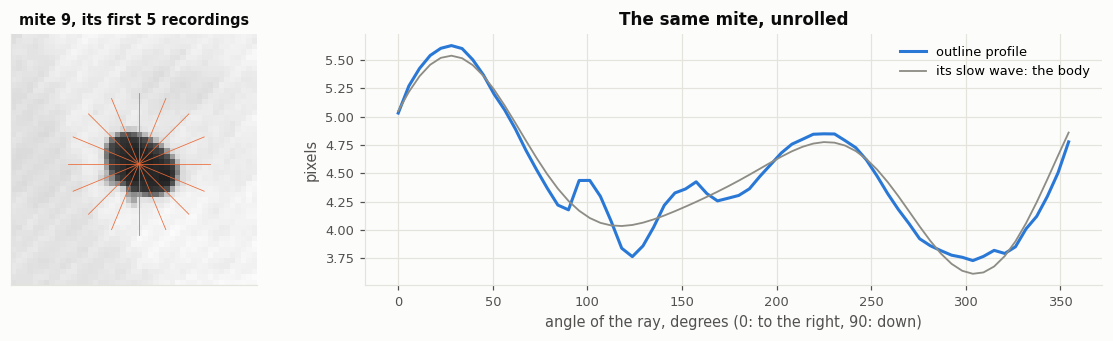

In [2]:
profiles = adf.outline_profiles(run, table)          # (mites, recordings, frames, angles), pixels
outline = profiles.mean(axis=2)                      # each recording's outline
degrees = np.arange(adf.ANGLES) * 360 / adf.ANGLES
n_frames = profiles.shape[2]

def smooth_body(outlines, harmonics=4):
    # the slow wave of an outline: its first harmonics in the angle
    spectrum = np.fft.rfft(outlines, axis=-1)
    spectrum[..., harmonics:] = 0
    return np.fft.irfft(spectrum, n=outlines.shape[-1], axis=-1)

example = int(np.flatnonzero(np.array(run.mites) == "9")[0])
image = images[example][:5].mean(axis=0)
x, y = table["x"][example, :5].mean(), table["y"][example, :5].mean()
start = outline[example, :5].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.2), gridspec_kw={"width_ratios": [1, 2.4]})
axes[0].imshow(image, cmap="gray", vmin=15, vmax=125)
for angle in np.radians(degrees[::4]):
    axes[0].plot([x, x + adf.REACH * np.cos(angle)], [y, y + adf.REACH * np.sin(angle)], color=ORANGE, linewidth=0.5)
axes[0].set_title(f"mite {run.mites[example]}, its first 5 recordings", fontsize=9.5)
axes[0].set_xlim(-0.5, image.shape[1] - 0.5); axes[0].set_ylim(image.shape[0] - 0.5, -0.5)
axes[0].set_xticks([]); axes[0].set_yticks([]); axes[0].grid(False)
axes[1].plot(degrees, start, color=BLUE, label="outline profile")
axes[1].plot(degrees, smooth_body(start), color=GREY, linewidth=1.2, label="its slow wave: the body")
axes[1].set(xlabel="angle of the ray, degrees (0: to the right, 90: down)", ylabel="pixels", title="The same mite, unrolled")
axes[1].legend()
plt.tight_layout()
plt.show()

## The legs through the run

Each panel is one mite. Across: the angle around the mite. Down: the run, one row per recording. The colour is the outline profile minus its slow wave, so what sticks out of the body is red. A leg is a red stripe; while it moves, the stripe wavers; when it stops for good, the stripe is straight.

The orange line is the last labelled movement. The black one is where the outline last changed shape between two recordings (see further down).

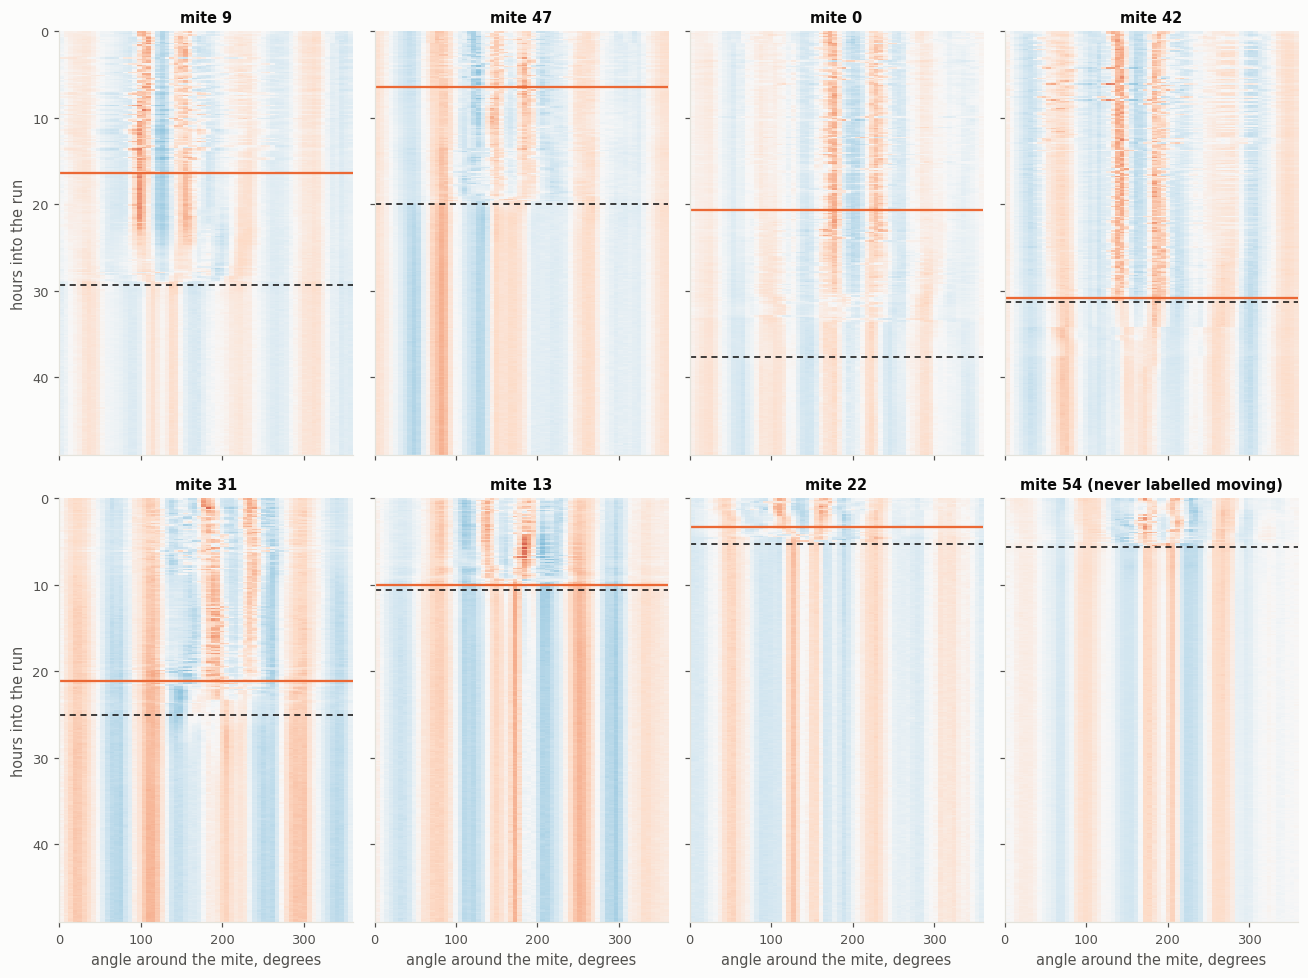

In [3]:
between = adf.over_angles(adf.shape_only(np.diff(outline, axis=1)))                 # (mites, recordings - 1, angles)
outline_change = np.concatenate([np.full((n_mites, 1), np.nan), adf.outline_movement(between)], axis=1)
# what two recordings of a mite that did nothing would differ by: the two halves of a recording's frames, brought to whole recordings
halves = adf.over_angles(adf.shape_only(profiles[:, :, 0::2].mean(axis=2) - profiles[:, :, 1::2].mean(axis=2)))
outline_floor = adf.outline_movement(halves) * np.sqrt(2 / n_frames) / np.sqrt(2 / (n_frames / 2))
OUTLINE_LIMIT = float(np.percentile(outline_floor[run.labelled & ~run.moving], 99.9))
legs_stop = adf.last_change(outline_change, OUTLINE_LIMIT)

sticking_out = outline - smooth_body(outline)
shown = [int(np.flatnonzero(np.array(run.mites) == name)[0]) for name in ("9", "47", "0", "42", "31", "13", "22", "54")]
fig, axes = plt.subplots(2, 4, figsize=(12, 9), sharex=True, sharey=True)
for ax, mite in zip(axes.ravel(), shown):
    ax.imshow(sticking_out[mite], aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1, extent=(0, 360, run.times[-1] / 60, 0), interpolation="nearest")
    if moved[mite]:
        ax.axhline(run.times[last[mite]] / 60, color=ORANGE, linewidth=1.5)
    ax.axhline(run.times[legs_stop[mite]] / 60, color=INK, linewidth=1, linestyle=(0, (4, 3)))
    ax.set_title(f"mite {run.mites[mite]}" + ("" if moved[mite] else " (never labelled moving)"), fontsize=9.5)
    ax.grid(False)
for ax in axes[-1]:
    ax.set_xlabel("angle around the mite, degrees")
for ax in axes[:, 0]:
    ax.set_ylabel("hours into the run")
plt.tight_layout()
plt.show()

## Within a recording: how far the outline moves

Each frame's profile is set against the mean of the recording's frames. The **outline movement** of a recording is the mean, over the 4 rays that move most, of how far each goes from its smallest to its largest over the frames: pixels of outline, where the movement score in use is a variance of grey levels.

,"AUC, moving against still",still: median,still: 999 in 1000 below,moving: median,"death error at its best threshold, recordings",that threshold
,,,,,,
"outline movement, pixels",0.996,0.093,0.267,0.361,4.153,0.266
movement score in use,0.997,1.572,3.888,6.406,3.492,4.175


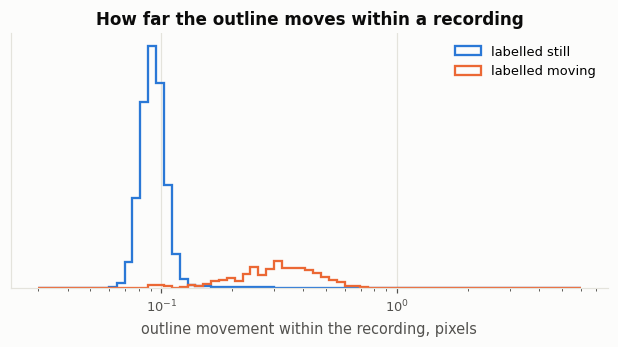

In [4]:
from classes import death_calibration
from classes.death_calibration import LabelledRun

within = adf.over_angles(adf.shape_only(profiles - profiles.mean(axis=2, keepdims=True)))    # (mites, recordings, frames, angles)
swing = within.max(axis=2) - within.min(axis=2)                                               # per ray, over the frames
movement = np.sort(swing, axis=-1)[..., -4:].mean(axis=-1)
is_still = run.labelled & ~run.moving

rows = []
for name, values in (("outline movement, pixels", movement), ("movement score in use", table["movement_score"])):
    threshold, error = death_calibration.best_threshold([LabelledRun(values, run.moving, run.labelled)])
    rows.append({"": name, "AUC, moving against still": adf.auc(values[run.moving], values[is_still]),
                 "still: median": np.median(values[is_still]), "still: 999 in 1000 below": np.percentile(values[is_still], 99.9),
                 "moving: median": np.median(values[run.moving]),
                 "death error at its best threshold, recordings": error, "that threshold": threshold})
display(pd.DataFrame(rows).set_index(""))

fig, ax = plt.subplots(figsize=(7, 3))
bins = np.geomspace(0.03, 6, 70)
ax.hist(movement[is_still], bins=bins, density=True, histtype="step", linewidth=1.5, color=BLUE, label="labelled still")
ax.hist(movement[run.moving], bins=bins, density=True, histtype="step", linewidth=1.5, color=ORANGE, label="labelled moving")
ax.set_xscale("log")
ax.set_yticks([])
ax.set(xlabel="outline movement within the recording, pixels", title="How far the outline moves within a recording")
ax.legend()
plt.show()

## Is it the legs that move?

If the movement is the legs', it sits where the legs are, and in the same place every time the mite moves. For each mite with at least 4 recordings labelled moving, the movement of each ray is summed over half of those recordings (what the still recordings show on that ray taken off), and the third of the outline that holds most of it is found. The other half of its moving recordings then says how much of *their* movement is in that third. By chance it would be a third.

Below, that third is drawn on the mite (orange), with the movement by angle under it.

46 mites with 4 or more recordings labelled moving: 81% of the outline's movement is in one third of the outline, chosen on the mite's other moving recordings (middle half: 76% to 85%)


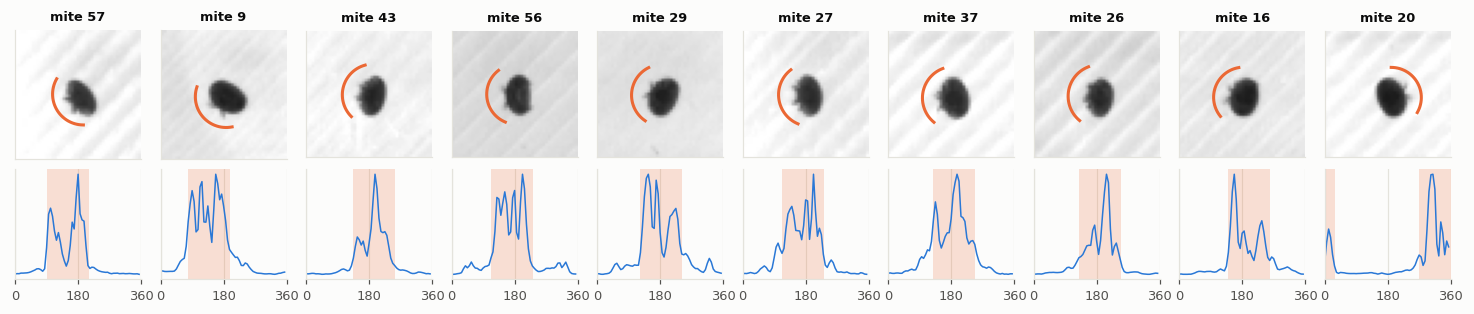

In [5]:
energy = (within ** 2).sum(axis=2)                                  # (mites, recordings, angles)
third = adf.ANGLES // 3

def in_third(by_angle):
    # (..., angles): the sum over the third of the outline that starts at each angle
    return sum(np.roll(by_angle, -shift, axis=-1) for shift in range(third))

shares, where = [], np.full(n_mites, -1)
excess = np.zeros_like(energy)
for mite in range(n_mites):
    moving_recordings = np.flatnonzero(run.moving[mite])
    if len(moving_recordings) < 4:
        continue
    excess[mite] = np.clip(energy[mite] - np.median(energy[mite][is_still[mite]], axis=0), 0, None)
    one, other = moving_recordings[0::2], moving_recordings[1::2]
    for chosen_on, judged_on in ((one, other), (other, one)):
        start = in_third(excess[mite][chosen_on].sum(axis=0)).argmax()
        total = excess[mite][judged_on].sum(axis=0)
        shares.append(in_third(total)[start] / total.sum())
    where[mite] = in_third(excess[mite][moving_recordings].sum(axis=0)).argmax()
print(f"{(where >= 0).sum()} mites with 4 or more recordings labelled moving: {np.median(shares):.0%} of the outline's movement is in one third "
      f"of the outline, chosen on the mite's other moving recordings (middle half: {np.percentile(shares, 25):.0%} to {np.percentile(shares, 75):.0%})")

shown = [mite for mite in np.argsort(-run.moving.sum(axis=1)) if where[mite] >= 0][:30:3]
fig, axes = plt.subplots(2, len(shown), figsize=(1.35 * len(shown), 2.9), gridspec_kw={"height_ratios": [1.3, 1]})
for column, mite in enumerate(shown):
    x, y = table["x"][mite, :5].mean(), table["y"][mite, :5].mean()
    axes[0, column].imshow(images[mite][:5].mean(axis=0), cmap="gray", vmin=15, vmax=125)
    arc = np.radians(degrees[where[mite]] + np.linspace(0, 120, 30))
    axes[0, column].plot(x + 11 * np.cos(arc), y + 11 * np.sin(arc), color=ORANGE, linewidth=2)
    axes[0, column].set_title(f"mite {run.mites[mite]}", fontsize=8.5)
    axes[0, column].set_xticks([]); axes[0, column].set_yticks([]); axes[0, column].grid(False)
    axes[1, column].plot(degrees, excess[mite][run.moving[mite]].sum(axis=0), color=BLUE, linewidth=1)
    axes[1, column].axvspan(degrees[where[mite]], degrees[where[mite]] + 120, color=ORANGE, alpha=0.2, linewidth=0)
    if degrees[where[mite]] + 120 > 360:
        axes[1, column].axvspan(0, degrees[where[mite]] + 120 - 360, color=ORANGE, alpha=0.2, linewidth=0)
    axes[1, column].set_yticks([]); axes[1, column].set_xticks([0, 180, 360]); axes[1, column].set_xlim(0, 360)
plt.tight_layout(w_pad=0.2)
plt.show()

## Between recordings: when the legs stop for good

The outline of one recording (the mean over its frames) is set against the one before: the **outline change** is the mean, over the 4 rays that changed most, of how far they changed, in pixels, with the change of shape only. It is the same question `dead_mite_change.ipynb` asks of the whole image, asked of the outline, and the answer comes in pixels.

A change counts when it is beyond what the camera's noise alone gives, measured within each recording as there. **The legs stop** at the last recording whose outline changed, the pair before it too.

,AUC,same time,same mite,"AUC, still in both against dead",alive: median,dead: median
,,,,,,
"outline change, pixels",0.979,0.982,0.974,0.970,0.111,0.021
"change of the whole image, grey levels",0.985,0.990,0.975,0.979,1.361,0.486


an outline has changed when it differs from the one before by more than 0.038 px: 91.9% of the alive recordings, 1.9% of the dead ones


,median,middle half from,to,within 5,more than 20 later
in recordings,,,,,
legs stop - end of change of the whole image,1.5,0.00,5.0,76%,19%
legs stop - last labelled movement,22.0,7.25,77.5,11%,52%


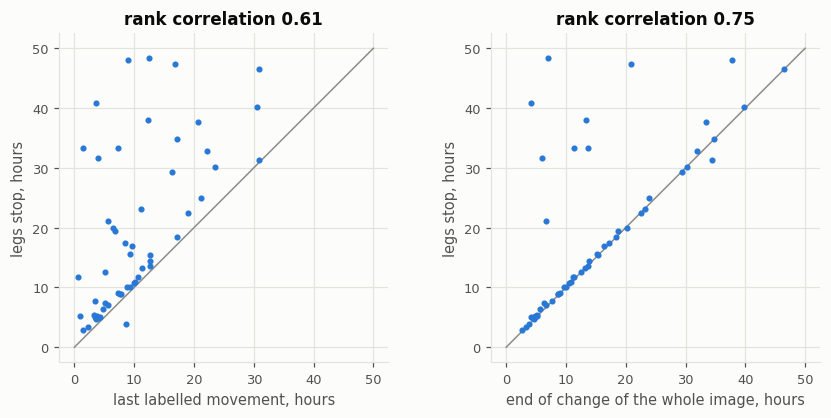

,"legs stop, hours","end of change of the whole image, hours"
mite never labelled moving,,
7,0.833,1.500
17,2.500,1.500
33,5.500,5.500
54,5.667,5.667
58,5.833,5.833


In [6]:
from scipy.stats import spearmanr

alive_pairs, dead_pairs, still_pairs = adf.both(group["alive"]), adf.both(group["dead"]), adf.both(group["alive_still"])
rows = []
for name, values in (("outline change, pixels", outline_change), ("change of the whole image, grey levels", table["image_change"])):
    result = adf.separation(values, alive_pairs, dead_pairs)
    rows.append({"": name, "AUC": result["auc"], "same time": result["same_time"], "same mite": result["same_mite"],
                 "AUC, still in both against dead": adf.auc(values[still_pairs], values[dead_pairs]),
                 "alive: median": np.nanmedian(values[alive_pairs]), "dead: median": np.nanmedian(values[dead_pairs])})
display(pd.DataFrame(rows).set_index(""))
print(f"an outline has changed when it differs from the one before by more than {OUTLINE_LIMIT:.3f} px: "
      f"{(outline_change[alive_pairs] > OUTLINE_LIMIT).mean():.1%} of the alive recordings, {(outline_change[dead_pairs] > OUTLINE_LIMIT).mean():.1%} of the dead ones")

CHANGE_LIMIT = float(np.percentile(table["noise_floor"][is_still], 99.9))
end_of_change = adf.last_change(table["image_change"], CHANGE_LIMIT)

def compare(name, difference):
    return {"in recordings": name, "median": np.median(difference), "middle half from": np.percentile(difference, 25),
            "to": np.percentile(difference, 75), "within 5": f"{np.mean(np.abs(difference) <= 5):.0%}",
            "more than 20 later": f"{np.mean(difference > 20):.0%}"}

display(pd.DataFrame([compare("legs stop - end of change of the whole image", (legs_stop - end_of_change)[moved]),
                      compare("legs stop - last labelled movement", (legs_stop - last)[moved])]).set_index("in recordings"))

fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))
for ax, reference, name in ((axes[0], last, "last labelled movement"), (axes[1], end_of_change, "end of change of the whole image")):
    ax.plot([0, 50], [0, 50], color=GREY, linewidth=1)
    ax.plot(run.times[reference[moved]] / 60, run.times[legs_stop[moved]] / 60, ".", color=BLUE, markersize=6)
    ax.set(xlabel=f"{name}, hours", ylabel="legs stop, hours", title=f"rank correlation {spearmanr(reference[moved], legs_stop[moved])[0]:.2f}")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()
display(pd.DataFrame([{"mite never labelled moving": run.mites[m], "legs stop, hours": run.times[legs_stop[m]] / 60,
                       "end of change of the whole image, hours": run.times[end_of_change[m]] / 60} for m in np.flatnonzero(~moved)])
        .set_index("mite never labelled moving"))

## What shrinks: the body or the legs?

`alive_dead_shrinkage.ipynb` could not say. The outline can be split: the **body** is the area inside the slow wave of the profile, and the **legs** are what sticks out of it. Both are followed from each mite's start, by the time since its legs stopped.

In [7]:
body = smooth_body(outline)
body_area = 0.5 * (body ** 2).sum(axis=-1) * 2 * np.pi / adf.ANGLES
leg_area = (np.clip(outline - body, 0, None) * body).sum(axis=-1) * 2 * np.pi / adf.ANGLES
print(f"at the start, what sticks out is {np.median(leg_area[:, :3] / body_area[:, :3]):.1%} of the body's area (median)")

rows = []
for first, end in [(-30, -5), (0, 10), (10, 30), (30, 60), (60, 120)]:
    row = {"recordings since the legs stopped": f"{first} to {end}"}
    for name, values in (("body", adf.since_start(body_area)), ("legs", adf.since_start(leg_area))):
        part = np.concatenate([values[m, max(legs_stop[m] + first, 0):max(legs_stop[m] + end, 0)] for m in np.flatnonzero(moved)])
        row[f"{name}, % since the start"] = 100 * np.median(part)
    rows.append(row)
display(pd.DataFrame(rows).set_index("recordings since the legs stopped"))
rows = [{"": name, **adf.separation(adf.since_start(values), group["alive"], group["dead"])} for name, values in (("body", body_area), ("legs", leg_area))]
display(pd.DataFrame(rows).set_index("").rename(columns={"auc": "AUC, alive against dead", "same_time": "same time", "same_mite": "same mite"}))

at the start, what sticks out is 2.6% of the body's area (median)


,"body, % since the start","legs, % since the start"
recordings since the legs stopped,,
-30 to -5,1.453,2.191
0 to 10,-1.002,5.768
10 to 30,-2.314,5.159
30 to 60,-3.791,3.612
60 to 120,-4.615,2.894


,"AUC, alive against dead",same time,same mite,distance
,,,,
body,0.942,0.978,0.952,1.747
legs,0.562,0.703,0.533,0.137


## What this is good for, and what not

**Good for**

- **Showing what happened to one mite.** The unrolled outline over the run is a picture of a mite's whole life on the plate, legs and all. For a mite whose death is in doubt, it shows at a glance when the legs last moved, which no score does.
- **A movement in pixels, at a place.** "The outline moved 0.4 px on the leg side" can be checked against the picture and compared between runs, cameras and lamps. A variance of grey levels cannot.
- **Telling a mite that moves from a plate that shakes.** A shift of the whole mite is taken out of the profile by construction, where the score in use needs the plate stabiliser for it. The frames here had already been through the stabiliser, and taking the shift out again changed the AUC only from 0.995 to 0.996, so this is untested.

**Not good for**

- **Replacing the score in use.** It separates moving from still as well, not better, and puts the deaths slightly worse.
- **Counting or naming legs.** A leg is a bump one to three rays wide. Two legs side by side are one bump, a leg tucked under the body is none, and the body's slow wave takes part of every leg with it. The split into body and legs used for the shrinking is rough for the same reason.
- **Other mites, as it stands.** These mites lie where they were put and do not walk. The centre is found anew in each recording, so a walking mite would be followed, but that was not tried.

**Not known**

- Whether it holds on another run. One plate, one lamp, one size of mite in pixels: at half the resolution a leg would be less than a pixel wide.